In [1]:
import os
base_path = os.getcwd()

In [2]:
import polars as pl

local_parquet_path = os.path.join(base_path, "data", "train.parquet")

# Menggunakan scan_parquet (Lazy) agar RAM tetap hemat
# Data hanya diproses saat .collect() dipanggil
df_pq = pl.scan_parquet(local_parquet_path)

In [3]:
df_sample = df_pq.head(15_000_000).collect()

print(f"Data berhasil disimpan di variabel 'df_sample'. Jumlah baris: {len(df_sample)}")
display(df_sample)

Data berhasil disimpan di variabel 'df_sample'. Jumlah baris: 15000000


ip,app,device,os,channel,click_time,attributed_time,is_attributed
i64,i64,i64,i64,i64,str,str,i64
83230,3,1,13,379,"""2017-11-06 14:32:21""",null,0
17357,3,1,19,379,"""2017-11-06 14:33:34""",null,0
35810,3,1,13,379,"""2017-11-06 14:34:12""",null,0
45745,14,1,13,478,"""2017-11-06 14:34:52""",null,0
161007,3,1,13,379,"""2017-11-06 14:35:08""",null,0
…,…,…,…,…,…,…,…
85065,12,2,40,265,"""2017-11-07 01:37:13""",null,0
113719,3,1,31,424,"""2017-11-07 01:37:13""",null,0
43547,3,1,13,480,"""2017-11-07 01:37:13""",null,0


In [4]:
from feature_engineering import generate_fraud_features, apply_heuristic_rules
from blocking_strategy import apply_business_blocking_strategy
df_sample = generate_fraud_features(df_sample)
df_sample = apply_heuristic_rules(df_sample)
df_sample = apply_business_blocking_strategy(df_sample)

In [5]:
from train_model import train_isolation_forest

features_to_use = [
    "click_hour", 
    "seconds_since_prev_click", 
    "ip_clicks_last_10m", 
    "fingerprint_clicks_last_1h", 
    "ip_unique_channels_per_hour", 
    "ip_rhythm_std_1h"
]

cari parameter contamination terbaik


🚀 MEMULAI MEMORY-SAFE HYPERPARAMETER TUNING
1. Menyiapkan matriks data utama...
2. Mentransfer data ke C-Array (NumPy)...
Data siap: 10,391,613 baris x 6 fitur.

-> Training dengan contamination = 0.01...
   Terdeteksi Bot: 103,917 | CR Bot: 0.4138% | CR Cleared: 0.1491%

-> Training dengan contamination = 0.03...
   Terdeteksi Bot: 311,692 | CR Bot: 0.3144% | CR Cleared: 0.1488%

-> Training dengan contamination = 0.05...
   Terdeteksi Bot: 519,579 | CR Bot: 0.2614% | CR Cleared: 0.1494%

-> Training dengan contamination = 0.07...
   Terdeteksi Bot: 727,413 | CR Bot: 0.2380% | CR Cleared: 0.1498%

-> Training dengan contamination = 0.1...
   Terdeteksi Bot: 1,039,162 | CR Bot: 0.2291% | CR Cleared: 0.1504%

-> Training dengan contamination = 0.15...
   Terdeteksi Bot: 1,558,741 | CR Bot: 0.2875% | CR Cleared: 0.1503%


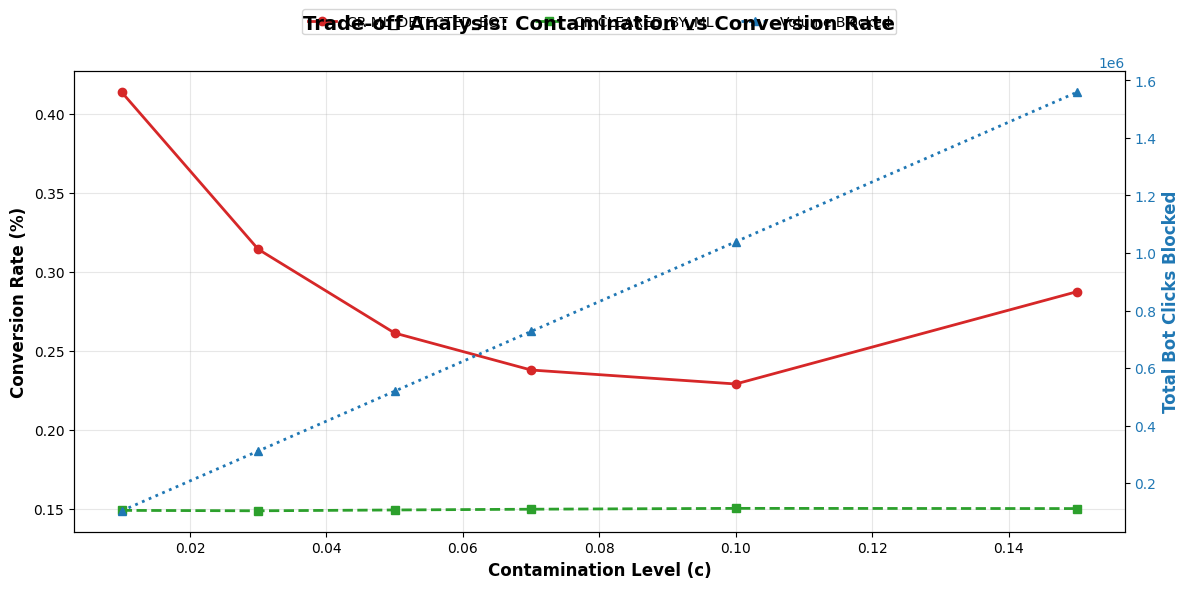

In [6]:
import gc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

print("\n" + "="*50)
print("🚀 MEMULAI MEMORY-SAFE HYPERPARAMETER TUNING")
print("="*50)

# =====================================================================
# TAHAP 1: PRE-KOMPUTASI (HANYA DILAKUKAN 1 KALI UNTUK MENGHEMAT RAM)
# =====================================================================
print("1. Menyiapkan matriks data utama...")
# Filter hanya data yang akan dilatih
df_train_base = df_sample.filter(pl.col("business_action") != "HARD_BLOCK_REJECT_PAYOUT")

# Imputasi nilai kosong dengan median
median_std = df_train_base.select(pl.col("ip_rhythm_std_1h")).median().to_series()[0]
safe_value = median_std if median_std is not None else 999
df_train_base = df_train_base.with_columns(pl.col("ip_rhythm_std_1h").fill_null(safe_value))

# Ekstraksi array yang dibutuhkan HANYA SEKALI
print("2. Mentransfer data ke C-Array (NumPy)...")
X_train = df_train_base.select(features_to_use).to_numpy()
y_true = df_train_base.select(pl.col("is_attributed")).to_numpy().flatten()
business_actions_base = df_train_base.select(pl.col("business_action")).to_numpy().flatten()

# HANCURKAN dataframe sementara yang memakan RAM besar
del df_train_base
gc.collect()

print(f"Data siap: {X_train.shape[0]:,} baris x {X_train.shape[1]} fitur.")

# =====================================================================
# TAHAP 2: LOOPING DENGAN GARBAGE COLLECTION EKSPLISIT
# =====================================================================
contamination_grid = [0.01, 0.03, 0.05, 0.07, 0.10, 0.15]
bot_crs = []
cleared_crs = []
bot_volumes = []

for c in contamination_grid:
    print(f"\n-> Training dengan contamination = {c}...")
    
    # Inisialisasi dan Train model
    iso_forest = IsolationForest(n_estimators=100, contamination=c, random_state=42, n_jobs=-1)
    predictions = iso_forest.fit_predict(X_train) # 1 = Normal, -1 = Anomaly
    
    # --- EVALUASI METRIK TANPA MEMBUAT DATAFRAME BARU ---
    # Buat boolean mask (True/False) untuk efisiensi komputasi NumPy
    mask_bot = (predictions == -1)
    mask_cleared = (predictions == 1) & (business_actions_base == "FLAG_FOR_ML")
    
    # Hitung metrik grup Bot
    bot_clicks = np.sum(mask_bot)
    bot_convs = np.sum(y_true[mask_bot])
    cr_bot = (bot_convs / bot_clicks * 100) if bot_clicks > 0 else 0.0
    
    # Hitung metrik grup Cleared
    cleared_clicks = np.sum(mask_cleared)
    cleared_convs = np.sum(y_true[mask_cleared])
    cr_cleared = (cleared_convs / cleared_clicks * 100) if cleared_clicks > 0 else 0.0
    
    # Simpan agregasi ke list (ukurannya hanya beberapa byte)
    bot_volumes.append(bot_clicks)
    bot_crs.append(cr_bot)
    cleared_crs.append(cr_cleared)
    
    print(f"   Terdeteksi Bot: {bot_clicks:,} | CR Bot: {cr_bot:.4f}% | CR Cleared: {cr_cleared:.4f}%")
    
    # PEMBERSIHAN MEMORI EKSPLISIT DI AKHIR ITERASI
    del iso_forest, predictions, mask_bot, mask_cleared
    gc.collect() # Paksa sistem operasi membersihkan RAM sekarang juga
# ==========================================
# VISUALISASI HASIL (DUAL-AXIS PLOT)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Sumbe Kiri: Conversion Rate
color1 = 'tab:red'
color2 = 'tab:green'
ax1.set_xlabel('Contamination Level (c)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
line1 = ax1.plot(contamination_grid, bot_crs, marker='o', color=color1, linewidth=2, label='CR ML_DETECTED_BOT')
line2 = ax1.plot(contamination_grid, cleared_crs, marker='s', color=color2, linestyle='--', linewidth=2, label='CR CLEARED_BY_ML')
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)

# Plot Sumbu Kanan: Volume Klik
ax2 = ax1.twinx()  
color3 = 'tab:blue'
ax2.set_ylabel('Total Bot Clicks Blocked', color=color3, fontsize=12, fontweight='bold')  
line3 = ax2.plot(contamination_grid, bot_volumes, marker='^', color=color3, linestyle=':', linewidth=2, label='Volume Blocked')
ax2.tick_params(axis='y', labelcolor=color3)

# Menggabungkan legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

plt.title('Trade-off Analysis: Contamination vs Conversion Rate', pad=30, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()